<table>
        <td>
        <td><img src="https://raw.githubusercontent.com/Fabian830348/Bases_Datos/refs/heads/master/logo_ECI.png" width="400"/></td>
        <td>&nbsp;</td>
        <td>
            <h1 style="font-size:200%;color:blue;text-align:center">    <FONT COLOR="blue"> Conceptos Machine Learning </p> Clasificación </p> Regresión Logística y Árboles de Decisión </FONT>         </h1></td>         
        <td>
            <tp><p style="font-size:99%;text-align:center">Machine Learning </p></tp>
            <tp><p style="font-size:115%;text-align:center">Diplomado 2026-2</p></tp>
            <tp><p style="font-size:115%;text-align:center">Prof. Fabián Sánchez</p></tp>
        </td>
    </tr>
</table>

En este notebook trabajaremos dos modelos importantes:

- Regresión logística

- Árboles de Decisión

A continuación veremos los elementos generales de estos modelos

# <FONT SIZE=5 COLOR="purple"> 1. Regresión Logística </FONT>

- Usamos regresión logística para estudiar la probabilidad de una variable categórica cualitativa (por ejemplo, dicotómica)  en función de una o más variables cuantitativas.

- En otras palabras, la regresión logística no permite clasificar directamente, pero si permite determinar una probabilidad de pertenecer a un grupo determinado de la variable categórica. Y luego, de acuerdo con esa probabilidad, tomar una decisión de asignación.

<FONT SIZE=4 COLOR="red"> Motivación al modelo </FONT>

Supongamos que tenemos una variable categórica con dos clase, que las llamaremos $\{0, 1\}$. Entonces, si tratamos de buscar un modelo lineal de la forma

$$y = \beta_0 +\beta_1 x_1 +\epsilon$$

donde $y$ es una variable binaria, no sería un bueno modelo ya que la izquierda de la expresión es continua. Luego, podríamos pensar en no tener una relación directa, sino vía la probabilidad, así:

$$P(y_i=1 \mid X = x_i)= \beta_0+\beta_1x_i$$

Cuando intentamos usar mínimos cuadrados, es fácil ver que el modelo no funciona ya que predecimos valores mayores que 1 y menores que 0.

<center><img src="https://github.com/Fabian830348/cursos/blob/0da91b828112d77dbddb387cbb7043ab8a78f252/Imagen/log1.png?raw=true" alt="centered image" width="500" height="400"></center>

podemos observar que este modelo no se ajusta a los datos. Más aún, si tratamos de predecir un valor, como $x=1.1$, al tratarse de una probabilidad, este valor no tiene sentido, pues es negativo.

Entonces, buscaremos una función cumpla lo siguiente

- $P(y_i=1 \mid X = x_i) = f(\beta_0 + \beta_1 x_i)$

- $P(y_i=1 \mid  x_i)$ sea creciente en $x$ para $\beta_1>0$.

- $P(y_i=1 \mid  x_i)$ sea decreciente en $x$ para $\beta_1<0$.

- $0 \leq P(y_i=1 \mid  x_i) \leq 1$ para todo valor de $x_i$.

Se puede ver rápidamente que la función debería tener una forma de S. A esta función se le denomina función sigmoide y es la base del modelo logístico

$$f(x)= \dfrac{e^x}{1+e^x}$$

La gráfica de esta función es:

<center><img src="https://github.com/Fabian830348/cursos/blob/0da91b828112d77dbddb387cbb7043ab8a78f252/Imagen/log2.png?raw=true" alt="centered image" width="500" height="400"></center>

Así pues, tenemos una expresión de la forma

$$P(y_i=1 \mid  X = x_i)= \dfrac{e^{\beta_0+\beta_1x_i}}{1+e^{\beta_0+\beta_1x_i}}$$

Una vez tengamos esta probabilidad se establece un umbral. Por defecto es 0.5, entonces

- Si $P(y_i=1 \mid  X = x_i) \geq  0.5$ entonces el valor $x_i$ es asignado a 1.

- Si $P(y_i=1 \mid  X = x_i) < 0.5$ entonces el valor $x_i$ es asignado a 0.


Veamos el ejemplo con el conjunto diabetes

## <FONT SIZE=4 COLOR="blue"> 1.1 Librerías de trabajo </FONT>

In [12]:
# Manipulación de data.frames
import pandas as pd
import numpy as np

# Librerías para Gráficos
import matplotlib.pyplot as plt
import seaborn           as sns
import plotly.express    as px

# Librerías para datos de entrenamiento y prueba
from sklearn.model_selection    import train_test_split

# Para preprocesamiento
from sklearn.preprocessing      import StandardScaler, MinMaxScaler

# Para aplicar k-nearest neiborg / logística
from sklearn.neighbors          import KNeighborsClassifier
from sklearn.linear_model       import LogisticRegression
from sklearn.tree               import DecisionTreeClassifier

# Métricas de evaluación
from sklearn.metrics            import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.metrics            import accuracy_score, precision_score, recall_score, f1_score
from imblearn.metrics           import specificity_score

# selección de características
from sklearn.feature_selection import RFE

# Optimización de hiperparámetros
from sklearn.model_selection    import GridSearchCV, RandomizedSearchCV

# Para ignorar los warnings
import warnings
warnings.filterwarnings("ignore")

In [13]:
def evaluacion_modelo(modelo, X_train, y_train, X_test, y_test, nombre_modelo = "modelo",graficar = True):
  # definir las predicciones en conjuntos de train y test
  y_pred_train = modelo.predict(X_train)
  y_pred_test  = modelo.predict(X_test)
  # matrices de confusión
  if graficar :
    # Calcular matrices de confusión
    cm_train = confusion_matrix(y_train, y_pred_train)
    cm_test = confusion_matrix(y_test, y_pred_test)
    # ejes para gráficas
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    # matriz de confusión en train
    sns.heatmap(pd.DataFrame(cm_train),                # data.frame
                  annot=True,                          # colocar números de las cajitas
                  annot_kws = {'size':20},             # tamaño de la letra
                  cmap="YlOrRd",                       # color de la letra 'Pastel1', 'Pastel1_r', 'Pastel2', 'Pastel2_r', 'PiYG', 'PiYG_r', 'PuBu'
                  fmt='g',                             # para que salgan los número no : notación científica
                  ax=axes[0])
    axes[0].set_title(f'Matriz de Confusión - Train-{nombre_modelo}', fontsize=14)
    axes[0].set_xlabel('Predicciones')
    axes[0].set_ylabel('Valores Reales')
    # matriz de confusión en test
    sns.heatmap(pd.DataFrame(cm_test),
              annot=True,
              fmt='g',
              cmap='YlOrRd',
              annot_kws={'size':20},
              ax=axes[1])
    axes[1].set_title(f'Matriz de Confusión - Test-{nombre_modelo}', fontsize=14)
    axes[1].set_xlabel('Predicciones')
    axes[1].set_ylabel('Valores Reales')
    plt.tight_layout()
    plt.show()
  # metricas en train
  metrics=["accuracy", "recall" , "specificity", "precision", "f1"]
  # valores
  values_train = [accuracy_score(y_train,y_pred_train),
          recall_score(y_train,y_pred_train),
          specificity_score(y_train,y_pred_train),
          precision_score(y_train,y_pred_train),
          f1_score(y_train,y_pred_train)]
  values_test = [accuracy_score(y_test,y_pred_test),
          recall_score(y_test,y_pred_test),
          specificity_score(y_test,y_pred_test),
          precision_score(y_test,y_pred_test),
          f1_score(y_test,y_pred_test)]

  df = pd.DataFrame({f"{nombre_modelo}_train" : values_train,
                      f"{nombre_modelo}_test" : values_test}, index = metrics)
  return df


## <FONT SIZE=4 COLOR="blue"> 1.2 Contexto del problema </FONT>

 En este caso intentaremos predecir a qué categoría corresponde un conjunto de datos.

En términos generales, seremos mucho más precisos si tenemos que modelar el comportamiento de una categoría que de una variable continua, por lo que veremos que muchas veces, incluso los problemas de predecir variables numéricas se pueden discretizar y convertir en problemas de clasificación.

En este caso, veremos un caso típico de un problema de clasificación. Queremos predecir si una integrante de una muestra que representa a una población, tiene diabetes. Queremos hacer esto a partir de múltiples variables que tenemos de cada uno de los pacientes:

- ***Pregnancies***: Número de embarazos que ha tenido en su vida
- ***Glucose***: Nivel de concentración de glucosa en sangre
- ***BloodPressure***: Presión arterial
- ***SkinThikness***: Espesor de piel a la altura del triceps
- ***Insulin***: Respuesta a dosis de insulina en 2 horas
- ***BMI***: Índice de masa corporal
- ***DiabetesPedigreeFunction***: Presencia de diabetes en ascendencia directa
- ***Age***: Edad del paciente
- ***Outcome***: Variable que queremos predecir:
   - $1$ : Tiene diabetes
   - $0$ : No tiene diabetes



## <FONT SIZE=4 COLOR="blue"> 1.3 Importar los datos </FONT>

Vamos a traer los datos del GitHub de la siguiente manera.

Lo primero que haremos es importar los datos que están en el siguiente link o pueden ser descargados de la página de Kaggle.

In [2]:
# cargar los datos
diabetes= pd.read_csv("https://raw.githubusercontent.com/Fabian830348/Bases_Datos/refs/heads/master/pima_diabetes_2000.csv")

In [3]:
# cabeza de los datos
diabetes.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,7,160,82,16,307,28.79,0.29,40,1
1,9,135,75,28,107,36.00,0.55,45,1
2,1,102,38,10,36,29.16,0.88,30,0
3,4,139,75,28,227,34.81,0.93,34,1
4,7,133,80,38,285,44.68,0.36,47,1


In [4]:
diabetes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               2000 non-null   int64  
 1   Glucose                   2000 non-null   int64  
 2   BloodPressure             2000 non-null   int64  
 3   SkinThickness             2000 non-null   int64  
 4   Insulin                   2000 non-null   int64  
 5   BMI                       2000 non-null   float64
 6   DiabetesPedigreeFunction  2000 non-null   float64
 7   Age                       2000 non-null   int64  
 8   Outcome                   2000 non-null   int64  
dtypes: float64(2), int64(7)
memory usage: 140.8 KB


## <FONT SIZE=4 COLOR="blue"> 1.4 Generación del Modelo Regresión Logística </FONT>

En el siguiente código encontrará los pasos

- Definir las variables
- Dividir en entrenamiento y prueba
- Escalar las variables
- Generar el modelo
- Entrenar el modelo
- Evaluar el modelo

In [ ]:
diabetes.head()

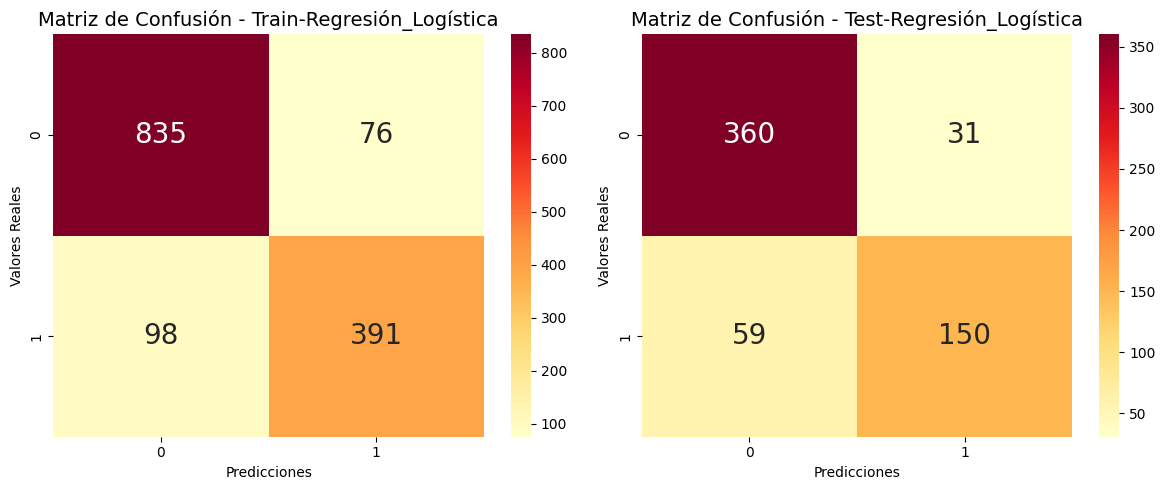

,Regresión_Logística_train,Regresión_Logística_test
accuracy,0.875714,0.850000
recall,0.799591,0.717703
specificity,0.916575,0.920716
precision,0.837259,0.828729
f1,0.817992,0.769231


In [15]:
# 1. definir variables
# variables predictoras
X = diabetes.drop("Outcome", axis=1)
# variable objetivo
y = diabetes.Outcome

# 2. train y test
X_train, X_test, y_train, y_test = train_test_split(X,                        # variables predictoras
                                                    y,                        # variable de respuesta
                                                    stratify = y,             # estratificar la muestra
                                                    random_state = 123,         # semilla para que al ejecutar siempre de igual
                                                    test_size = 0.3)          # tamaño del conjunto de prueba

# 3. escalar los datos
# esta es la función para escalar los datos
escalar = StandardScaler()
# escalar tanto el X_train como el X_test.
X_train_s = escalar.fit_transform(X_train)
X_test_s = escalar.transform(X_test)

# 4. Modelo de regresión logística
modelo_log = LogisticRegression(random_state=123)

# 5. Entrenamiento
modelo_log.fit(X_train_s, y_train)

# 6. Evaluación del modelo
evaluacion_modelo(modelo_log, X_train_s, y_train, X_test_s, y_test, nombre_modelo = "Regresión_Logística",graficar = True)


Podemos ver las variables más importantes en el modelo

In [16]:
# Le indico que me seleccione las 5 variables más importantes
rfe=RFE(modelo_log, n_features_to_select=5)
rfe.fit(X_train, y_train)
rfe.ranking_
X.columns[rfe.ranking_== 1]

Index(['Pregnancies', 'Glucose', 'BMI', 'DiabetesPedigreeFunction', 'Age'], dtype='object')

Comparemos con el modelo de los vecinos más cercanos



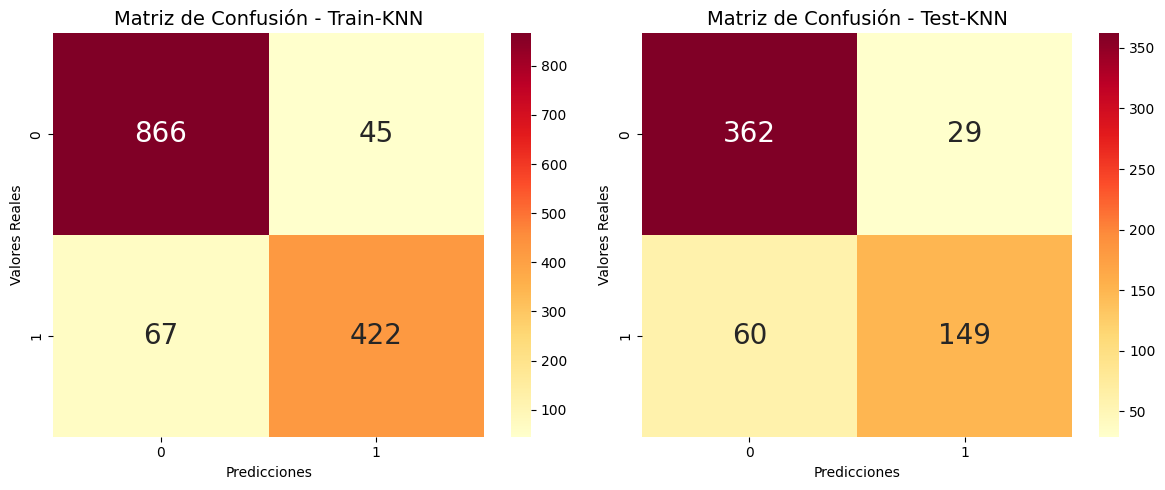

,KNN_train,KNN_test
accuracy,0.920000,0.851667
recall,0.862986,0.712919
specificity,0.950604,0.925831
precision,0.903640,0.837079
f1,0.882845,0.770026


In [17]:
# 1. definir variables
# variables predictoras
X = diabetes.drop("Outcome", axis=1)
# variable objetivo
y = diabetes.Outcome

# 2. train y test
X_train, X_test, y_train, y_test = train_test_split(X,                        # variables predictoras
                                                    y,                        # variable de respuesta
                                                    stratify = y,             # estratificar la muestra
                                                    random_state = 123,         # semilla para que al ejecutar siempre de igual
                                                    test_size = 0.3)          # tamaño del conjunto de prueba

# 3. escalar los datos
# esta es la función para escalar los datos
escalar = StandardScaler()
# escalar tanto el X_train como el X_test.
X_train_s = escalar.fit_transform(X_train)
X_test_s = escalar.transform(X_test)

# 4. Modelo de regresión logística
modelo_knn = KNeighborsClassifier()

# 5. Entrenamiento
modelo_knn.fit(X_train_s, y_train)

# 6. Evaluación del modelo
evaluacion_modelo(modelo_knn, X_train_s, y_train, X_test_s, y_test, nombre_modelo = "KNN",graficar = True)


In [18]:
df_final = pd.DataFrame(
    [
        metricas_log.set_index('metrics')['values_log'],
        metricas_knn.set_index('metrics')['values_knn']
    ],
    index=['Logistic Regression', 'KNN']
)

df_final

metrics,accuracy,recall,specificidad,precision,f1
Logistic Regression,0.850000,0.717703,0.920716,0.828729,0.769231
KNN,0.851667,0.712919,0.925831,0.837079,0.770026


## <FONT SIZE=4 COLOR="blue"> 1.5 Hiperparámetros de la regresión logística </FONT>

La regresión logística tiene los siguientes hiperparámetros

1. *penalty* : Parámetro de regularización. Es una técnica para evitar el sobreajuste (**overfitting)**

$$Funcion\_de\_Costo = Log\_Loss + Penalizacion$$

Esta penalización puede ser $L1$ que se llama Lasso y $L2$ que se llama Ridge

**Regularización *L2* (Ridge)**

Penaliza la suma de los cuadrados de los coeficientes

$$\lambda \sum \limits_{j=1}^n \beta_{j}^2$$

   - Empuja los coeficientes hacia valores pequeños, pero no los anula

   - Mantiene todas las variables del modelo.

**Regularización *L1* Lasso**

Penaliza la suma del valor absoluto de los coeficientes

$$\lambda \sum \limits_{j=1}^n |\beta_{j}|$$

   - Tiene el efecto de que algunos coeficientes se vuelven cero.

   - Selección automática de variables.

**Elastic Net : *L1+L2***

$$\lambda_1 \sum \limits_{j=1}^n \beta_{j}^2+\lambda_2 \sum \limits_{j=1}^n |\beta_{j}|$$


En resumen, la función de pérdida queda

$$ -\dfrac{1}{n}\sum \limits_{i=1}^n [y_i\log(\hat{y_i})+(1-y_i)\log(1-\hat{y_i})] + \lambda \sum \limits_{j=1}^n \beta_{j}^2$$

o

$$ -\dfrac{1}{n}\sum \limits_{i=1}^n [y_i\log(\hat{y_i})+(1-y_i)\log(1-\hat{y_i})] + \lambda \sum \limits_{j=1}^n |\beta_{j}|$$

2. *Solver*: Parámetro de optimización. Algoritmo utilizado para optimizar

 - *liblinear* : soporta L1 y L2. Para conjunto pequeños de datos.

 - *saga*: conjuntos de datos grandes. Soporta L1, L2 y Elasticnet.

 - *lbfga*: problemas multiclase con L2

 - *newtin-cg*. Es útil en multiclase.

3. Hiperparámetro *C*

En *LogisticRegression* de scikit-learn, no se usa $\lambda$ sino el inverso

$$C = \dfrac{1}{\lambda}$$

  - C grande, implica $\lambda$ pequeño: menos regularización.

  - C pequeño, implica $\lambda$ grande: más regularización.

  - C = [0.001, 0.01 , 0.1 , 1 , 10 , 100 , 1000]



In [20]:
# optimización de hiperparámetros
from sklearn.pipeline import Pipeline
# Crear pipeline con escalador y modelo
pipe = Pipeline(steps=[
      ('scaler', StandardScaler()),
      ('reg_log', LogisticRegression())
      ])

# definimos los parámetros que vamos a combinar. Diccionario
grid_params = {"reg_log__penalty": ["l1", "l2"],
               "reg_log__C": [0.001, 0.01, 0.1, 1, 10, 100],
               "reg_log__solver": ["liblinear", "lbfgs", "saga"],
               "reg_log__max_iter": [100, 500, 1000]}

# hacemos la búsqueda en grilla con 5-folds
Grid = GridSearchCV(pipe,                        # el modelo aplicado
                    grid_params,                 # los parámetros que van a variar
                    cv = 10,                     # el número de folds
                    verbose = 1)                 # para que imprima resultados. Posibilidades: 1,2 o 3
# Entrenar el modelo obtenido arriba
g_res = Grid.fit(X_train,y_train)

Fitting 10 folds for each of 108 candidates, totalling 1080 fits


In [21]:
# el mejor accuracy
print("Mejor score: ",g_res.best_score_)
# los mejores hiperparámetros
print("Mejores hiperparámetros", g_res.best_params_)
# el mejor modelo
modelo_log_best = g_res.best_estimator_

Mejor score:  0.8728571428571428
Mejores hiperparámetros {'reg_log__C': 1, 'reg_log__max_iter': 100, 'reg_log__penalty': 'l1', 'reg_log__solver': 'liblinear'}


In [23]:
diabetes_predicciones = pd.read_csv("https://raw.githubusercontent.com/Fabian830348/Bases_Datos/refs/heads/master/pima_diabetes_100_para_predecir.csv")
diabetes_predicciones.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,167,90,17,266,33.01,0.202,55
1,3,95,60,24,60,30.57,0.655,28
2,5,90,70,34,61,35.34,0.400,24
3,7,140,74,7,40,26.58,0.319,48
4,4,94,64,23,20,27.79,0.421,33


In [24]:
probabilidades = modelo_log_best.predict_proba(diabetes_predicciones)[:,1]

In [25]:
predicciones = modelo_log_best.predict(diabetes_predicciones)

In [26]:
# predicciones y las probabilidades
diabetes_predicciones["predicciones"] = predicciones
diabetes_predicciones["probab"] = probabilidades
diabetes_predicciones.head(5)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,predicciones,probab
0,6,167,90,17,266,33.01,0.202,55,1,0.927714
1,3,95,60,24,60,30.57,0.655,28,0,0.032047
2,5,90,70,34,61,35.34,0.400,24,0,0.046302
3,7,140,74,7,40,26.58,0.319,48,0,0.494021
4,4,94,64,23,20,27.79,0.421,33,0,0.018203


# <FONT SIZE=5 COLOR="purple"> 2. Árboles de Decisión </FONT>

- El enfoque de clasificación y regresión vía árboles (CART, classification and regression tree) fue desarrollado por Breiman et al. (1984).

- Un árbol de decisión es una estructura que incluye un ***nodo raíz, nodos principales, ramas y nodos hoja***. Cada nodo interno denota una prueba sobre un atributo, cada rama denota el resultado de una prueba y cada nodo hoja contiene una etiqueta de clase. El nodo superior del árbol también es llamado: **nodo raíz**.

<br>
<center><img src="https://github.com/Fabian830348/cursos/blob/master/tree/tree1.png?raw=true" alt="centered image" width="500" height="350"></center> <center><figcaption> <FONT SIZE=1 COLOR="black"> Fuente: Elaboración propia  </FONT> <figcaption></center>
<br>

Los términos que intervienen en el algoritmo de árbol de decisión son los siguientes

- ***Nodo raíz:***: Es el nodo inicial del árbol.

- ***División:*** Es un proceso de división de un nodo en dos o más subnodos.

- ***Nodo de decisión***: Cuando un subnodo se divide en otros subnodos, se denomina nodo de decisión.

- ***Nodo hoja/terminal***: Son los nodos que no se dividen más.

- ***Rama/Subárbol***:  Una subsección de un árbol completo que inicia con un nodo principal.

- ***Profundidad:*** Es el número de niveles de decisión en el árbol.

- ***Poda***: Es el proceso de eliminar nodos de decisión con el fin de hacer el árbol más pequeño

Esta técnica de machine learning toma una serie de decisiones binarias en forma de árbol. Los nodos intermedios (las ramas) representan soluciones y los nodos finales (las hojas) nos dan la predicción que buscamos.

Para seleccionar las condiciones que conforman el árbol se usan dos elementos que se describirán más adelante.

  - Indice de Gini
  - Ganancia de Información (Entropía)


Lo primero que debemos indicar es que el algoritmo se basa en una serie de decisiones binarias, que gráficamente, no es más que una división de una región del plano donde están los datos.

<br>
<center><img src="https://github.com/Fabian830348/cursos/blob/master/tree/tree2.png?raw=true" alt="centered image" width="650" height="400"></center> <center><figcaption> <FONT SIZE=1 COLOR="black"> Fuente: Elaboración propia  </FONT> <figcaption></center>
<br>

Esta división se hace con el fin de separar un conjunto de puntos en las clases correspondientes. Consideremos el siguiente conjunto de puntos:

$$\{(x_i,y_i) \mid i = 1,2,3, \dots 29\}$$

<center><img src="https://github.com/Fabian830348/cursos/blob/master/tree/tree13.png?raw=true" alt="centered image" width="650" height="400"></center> <center><figcaption> <FONT SIZE=1 COLOR="black"> Fuente: Elaboración propia  </FONT> <figcaption></center>
<br>

Buscamos hacer divisiones rectangulares con el fin de separar los puntos. Para esto debemos iniciar con una condición, pero ¿cómo se hace esto?

Para responder está pregunta debemos hacer una grilla o cuadrícula tomando como referencia puntos entre cada $(x_i,x_{i+1}$) y $(y_i,y_{i+1})$.Por lo general se toma el punto medio

<br>
<center><img src="https://github.com/Fabian830348/cursos/blob/master/tree/tree3.png?raw=true" alt="centered image" width="650" height="400"></center> <center><figcaption> <FONT SIZE=1 COLOR="black"> Fuente: Elaboración propia  </FONT> <figcaption></center>
<br>

Ahora, debemos determinar cuál condición $x \leq x_i$ o $y \leq y_j$ es más apropiada para iniciar. Esta condición nos dará el nodo raíz que es el inicio del algoritmo.

Es en este punto donde debemos tener un criterio de decisión. Para ello hay dos alternativas: usar el índice de Gini o la Entropía, con el fin de determinar la mejor condición.

- El índice de Gini dice que, si seleccionamos al azar dos elementos de una población, deben ser de la misma clase y la probabilidad de que esto ocurra es 1 si la población es pura. En otras palabras, este índice permite determinar si un conjunto de puntos es homogéneo o no.

- Este índice funciona con la variable objetivo categórica "Éxito" o "Fracaso". Sólo realiza divisiones binarias.

*Cuanto menor sea el valor de Gini, mayor será la homogeneidad.*

- El **índice de Gini** está dado en general como:

$$Gini = 1-\sum \limits_{k=1}^{n}p_k^2$$

donde $p_k$ es la probabilidad de seleccionar un objeto de la clase $k$ en un determinado nodo.

Veamos un ejemplo de dos condiciones:

<br>
<center><img src="https://github.com/Fabian830348/cursos/blob/master/tree/tree14.png?raw=true" alt="centered image" width="650" height="350"></center> <center><figcaption> <FONT SIZE=1 COLOR="black"> Fuente: Elaboración propia  </FONT> <figcaption></center>
<br>

Ahora bien, para determinar si elegimos una condición o no, usaremos el concepto de *impureza*, que se define de la siguiente manera

$$\text{Impureza de un nodo} = (Gini) \times (\text{Ponderacion de los nodos})$$

Supongamos que en nuestro ejemplo ( de los puntos dados arriba) queremos saber cuál condición es mejor, es decir, tiene un nivel de impureza menor.

<br>
<center><img src="https://github.com/Fabian830348/cursos/blob/master/tree/tree5.png?raw=true" alt="centered image" width="650" height="400"></center> <center><figcaption> <FONT SIZE=1 COLOR="black"> Fuente: Elaboración propia  </FONT> <figcaption></center>
<br>

Es importante resaltar que el algoritmo compara todas las impurezas y escoje la menor. En ese sentido, la función de costo para los árboles de clasificación es:

$$\text{función de costo} = 1-\sum \limits_{k=1}^{n}p_k^2$$

Partiendo de esta condición, comenzamos la división en el árbol buscando minimizar esta función.

En las siguientes imágenes se observan las divisiones del árbol para diferentes valores

<br>
<center><img src="https://github.com/Fabian830348/cursos/blob/master/tree/tree4.png?raw=true" alt="centered image" width="650" height="350"></center> <center><figcaption> <FONT SIZE=1 COLOR="black"> Fuente: Elaboración propia  </FONT> <figcaption></center>
<br>

<center><img src="https://github.com/Fabian830348/cursos/blob/master/tree/tree6.png?raw=true" alt="centered image" width="650" height="350"></center> <center><figcaption> <FONT SIZE=1 COLOR="black"> Fuente: Elaboración propia  </FONT> <figcaption></center>
<br>
<center><img src="https://github.com/Fabian830348/cursos/blob/master/tree/tree7.png?raw=true" alt="centered image" width="650" height="350"></center> <center><figcaption> <FONT SIZE=1 COLOR="black"> Fuente: Elaboración propia  </FONT> <figcaption></center>
<br>

**Observación:** El método de árboles de decisión busca minimizar el índice de Gini y esto se puede lograr dividiendo el árbol de manera exhaustiva. Es decir, practicamente que cada punto este en una región. Pero esto es malo, ya que estamos *sobreajustando* el modelo. En otras palabras, el modelo clasifica perfectamente los datos del conjunto de entrenamiento pero no clasificará bien en los datos de prueba.

Veamos el código en Python

In [ ]:
diabetes.head()

**Modelo de árboles completo**

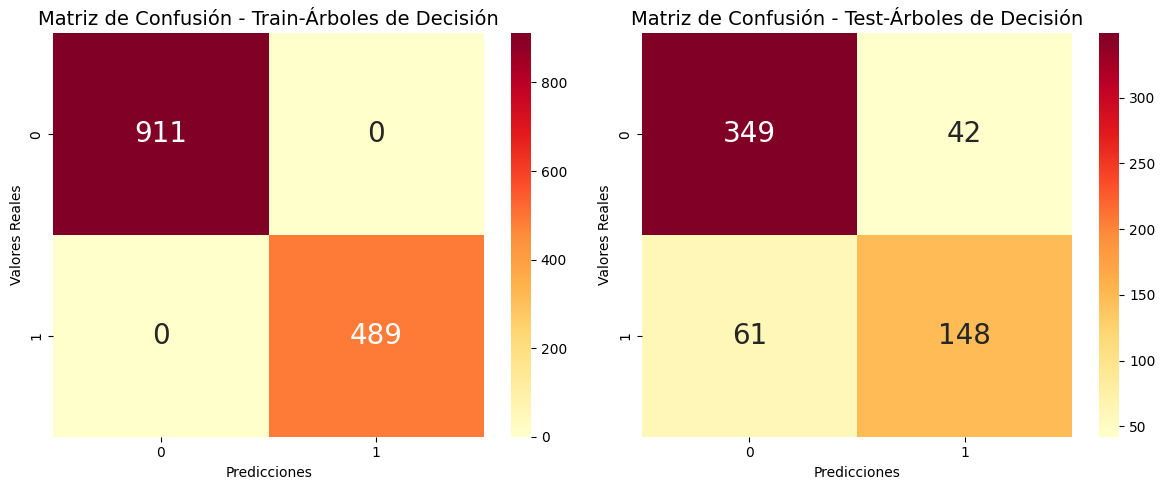

,Árboles de Decisión_train,Árboles de Decisión_test
accuracy,1.0,0.828333
recall,1.0,0.708134
specificity,1.0,0.892583
precision,1.0,0.778947
f1,1.0,0.741855


In [27]:
# 1. definir variables
# variables predictoras
X = diabetes.drop("Outcome", axis=1)
# variable objetivo
y = diabetes.Outcome

# 2. train y test
X_train, X_test, y_train, y_test = train_test_split(X,                        # variables predictoras
                                                    y,                        # variable de respuesta
                                                    stratify = y,             # estratificar la muestra
                                                    random_state = 123,         # semilla para que al ejecutar siempre de igual
                                                    test_size = 0.3)          # tamaño del conjunto de prueba

# 3. no es necesario escalar los datos

# 4. Modelo de árboles de decisión
modelo_tree = DecisionTreeClassifier()

# 5. Entrenamiento
modelo_tree.fit(X_train, y_train)

# 6. Evaluación del modelo
evaluacion_modelo(modelo_tree, X_train, y_train, X_test, y_test, nombre_modelo = "Árboles de Decisión",graficar = True)

Con base en la información anterior podemos indicar que hay sobreajuste

Profundidad del árbol: 17
Número de nodos terminales: 144


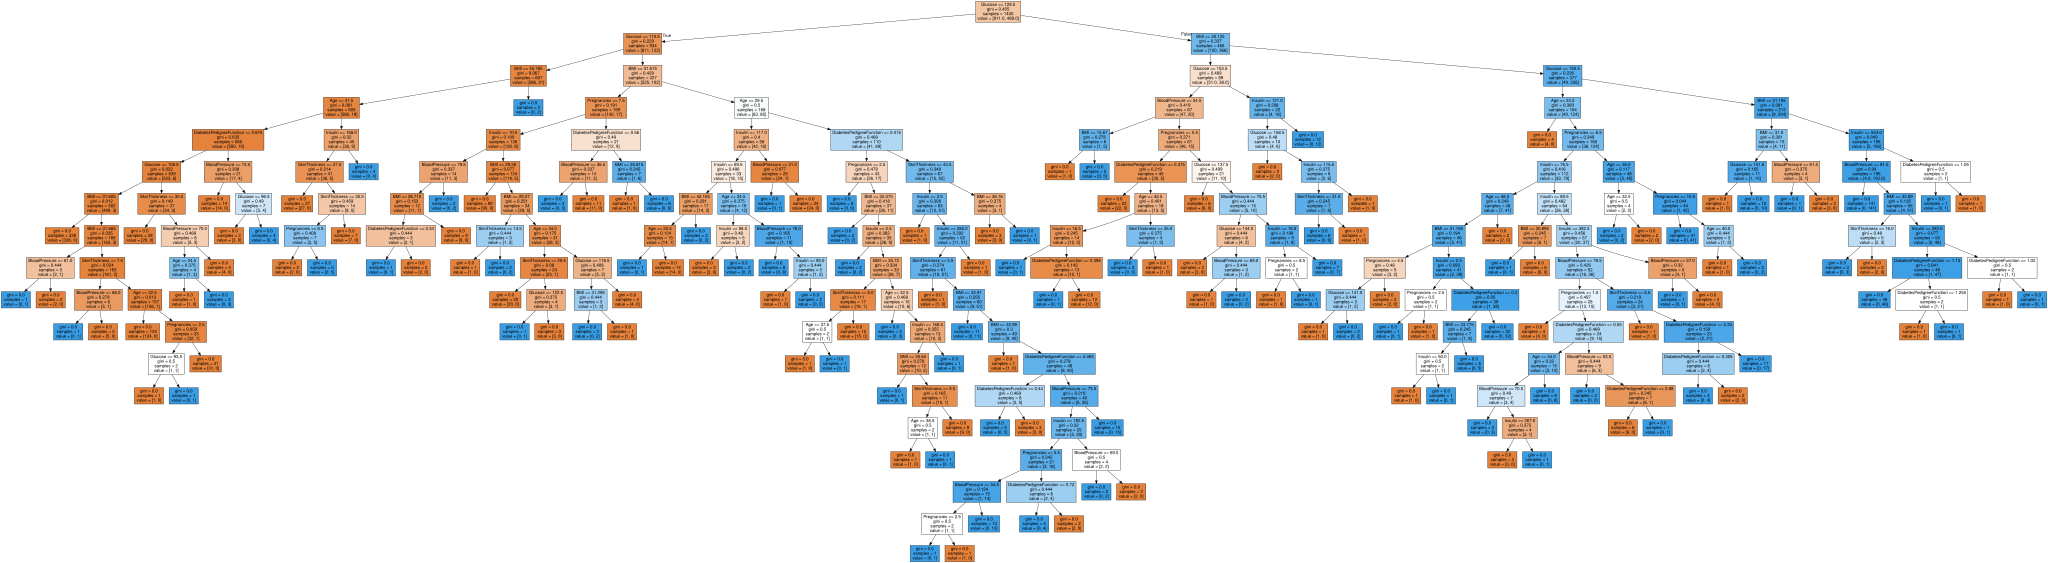

In [28]:
# graficar el árbol completo
from sklearn.tree             import export_graphviz
from graphviz                 import Source

# Revisamos la profundidad y el número de nodos terminales
print(f"Profundidad del árbol: {modelo_tree.get_depth()}")
print(f"Número de nodos terminales: {modelo_tree.get_n_leaves()}")
# Generamos el árbol
dot_data = export_graphviz(modelo_tree,                           # modelo
                           feature_names = X.columns,            # columnas de entrenamiento
                           filled=True,)                         # colores del árbol (relleno)
Source(dot_data, format="png")

In [29]:
# revisar la importancia de las variables
print("Importancia de los predictores en el modelo")
print("-------------------------------------------")
importancia_predictores = pd.DataFrame(
    {'predictor': X_train.columns.tolist(),
     'importancia': modelo_tree.feature_importances_}
)
importancia_predictores.sort_values('importancia', ascending=False)

Importancia de los predictores en el modelo
-------------------------------------------


,predictor,importancia
1,Glucose,0.522973
5,BMI,0.139916
4,Insulin,0.074293
2,BloodPressure,0.062772
7,Age,0.061709
6,DiabetesPedigreeFunction,0.057697
0,Pregnancies,0.045405
3,SkinThickness,0.035234


Vamos a comparar los modelos

In [31]:
# dataframe con las metricas de knn y reg_log
df_knn_t = metricas_knn.set_index('metrics').T
df_knn_t.index = ['knn']

df_log_t = metricas_log.set_index('metrics').T
df_log_t.index = ['Logistic']

df_tree_t = metricas_tree.set_index('metrics').T
df_tree_t.index = ['Tree']

df_final = pd.concat([df_knn_t, df_log_t, df_tree_t])

df_final

metrics,accuracy,recall,specificidad,precision,f1
knn,0.851667,0.712919,0.925831,0.837079,0.770026
Logistic,0.850000,0.717703,0.920716,0.828729,0.769231
Tree,0.831667,0.698565,0.902813,0.793478,0.743003


**Modelo de árboles pero con profundidad 3**

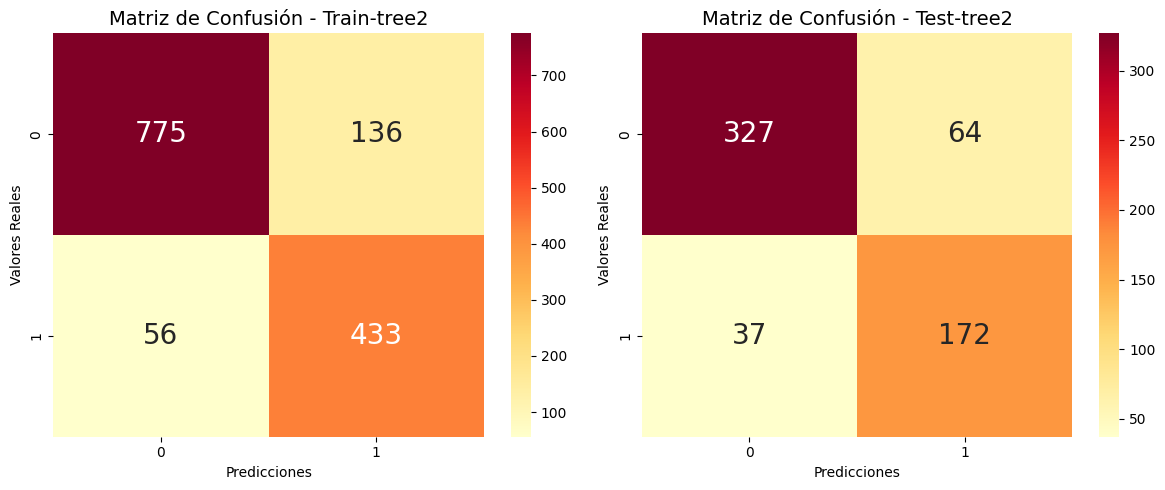

,tree2_train,tree2_test
accuracy,0.862857,0.831667
recall,0.885481,0.822967
specificity,0.850714,0.836317
precision,0.760984,0.728814
f1,0.818526,0.773034


In [32]:
# cambiar la profundidad
# 1. definir variables
# variables predictoras
X = diabetes.drop("Outcome", axis=1)
# variable objetivo
y = diabetes.Outcome

# 2. train y test
X_train, X_test, y_train, y_test = train_test_split(X,                        # variables predictoras
                                                    y,                        # variable de respuesta
                                                    stratify = y,             # estratificar la muestra
                                                    random_state = 123,         # semilla para que al ejecutar siempre de igual
                                                    test_size = 0.3)          # tamaño del conjunto de prueba

# 3. No vamos a escalar los datos : no es recomendable

# 4. Modelo
modelo_tree2= DecisionTreeClassifier(random_state=123,
                                     max_depth=3)

# 5. Entrenamiento
modelo_tree2.fit(X_train, y_train)

# 6. Evaluación del modelo
evaluacion_modelo(modelo_tree2, X_train, y_train, X_test, y_test, nombre_modelo = "tree2",graficar = True)

Profundidad del árbol: 3
Número de nodos terminales: 8


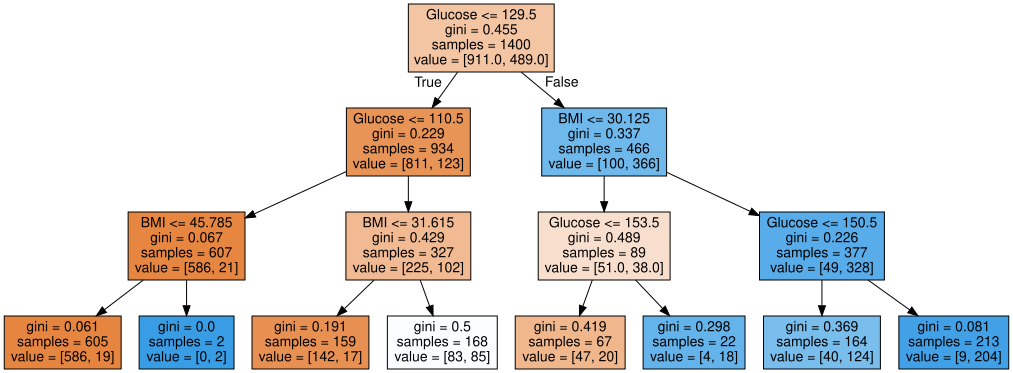

In [33]:
# Revisamos la profundidad y el número de nodos terminales
print(f"Profundidad del árbol: {modelo_tree2.get_depth()}")
print(f"Número de nodos terminales: {modelo_tree2.get_n_leaves()}")
# Generamos el árbol
dot_data3 = export_graphviz(modelo_tree2,                           # modelo
                           feature_names = X.columns,            # columnas de entrenamiento
                           filled=True,)                         # colores del árbol (relleno)
Source(dot_data3, format="png")

In [35]:
# revisar la importancia de las variables
print("Importancia de los predictores en el modelo")
print("-------------------------------------------")
importancia_predictores = pd.DataFrame(
    {'predictor': X_train.columns.tolist(),
     'importancia': modelo_tree2.feature_importances_}
)
importancia_predictores.sort_values('importancia', ascending=False)

Importancia de los predictores en el modelo
-------------------------------------------


,predictor,importancia
1,Glucose,0.844404
5,BMI,0.155596
2,BloodPressure,0.000000
0,Pregnancies,0.000000
3,SkinThickness,0.000000
4,Insulin,0.000000
6,DiabetesPedigreeFunction,0.000000
7,Age,0.000000


## <FONT SIZE=4 COLOR="blue"> 2.1 Hiperparámetros de los árboles de decisión </FONT>

En los árboles de decisión tenemos los siguientes hiperparámetros

- **criterion**: mide la calidad de la división (gini suele ser más rápido, entropy más informativo, log_loss es más reciente en scikit-learn ≥ 1.1).

- **max_depth**: controla la complejidad del árbol (None = crece hasta que no pueda más).

- **min_samples_split**: mínimos de muestras en un nodo para dividir

- **min_samples_leaf**: asegura que cada hoja tenga un número mínimo de observaciones.

- **max_features**: reduce el número de variables candidatas por división (útil en ensambles).

- **splitter**: best elige la mejor división, random añade aleatoriedad (a veces útil).

**Nota:** Los más usados son el criterion y la profundidad.


In [ ]:
# Modelo
modelo=DecisionTreeClassifier()

# definimos los parámetros que vamos a combinar. Diccionario
grid_params = {
    "criterion": ["gini", "entropy"],               # función de impureza
    "max_depth": [None] + list(range(2, 12))        # profundidad máxima
}

# hacemos la búsqueda en grilla con 5-folds
grid_tree = GridSearchCV(modelo,                             # el modelo aplicado
                         grid_params,                             # los parámetros que van a variar
                         cv = 10,                                 # el número de folds
                         scoring = "accuracy",                    # la métrica de evaluación
                         verbose = 3)                             # para que imprima resultados. Posibilidades: 1,2 o 3

# Entrenar el modelo obtenido arriba
modelo_tree_grid = grid_tree.fit(X_train,y_train)

In [37]:
# el mejor accuracy
print("Mejor score: ",modelo_tree_grid.best_score_)
# los mejores hiperparámetros
print("Mejores hiperparámetros",modelo_tree_grid.best_params_)
# el mejor modelo
modelo_tree_best = modelo_tree_grid.best_estimator_

Mejor score:  0.8678571428571429
Mejores hiperparámetros {'criterion': 'gini', 'max_depth': 5}


## <FONT SIZE=4 COLOR="blue"> 2.2 Importancia de las características </FONT>



In [38]:
modelo_tree_best.feature_importances_

array([0.02733834, 0.71998019, 0.00857128, 0.        , 0.03166048,
       0.14140386, 0.03278089, 0.03826497])

In [39]:
print("Importancia de los predictores en el modelo")
print("-------------------------------------------")
importancia_predictores = pd.DataFrame(
    {'predictor': X_train.columns.tolist(),
     'importancia': modelo_tree_best.feature_importances_}
)
importancia_predictores.sort_values('importancia', ascending=False)

Importancia de los predictores en el modelo
-------------------------------------------


,predictor,importancia
1,Glucose,0.719980
5,BMI,0.141404
7,Age,0.038265
6,DiabetesPedigreeFunction,0.032781
4,Insulin,0.031660
0,Pregnancies,0.027338
2,BloodPressure,0.008571
3,SkinThickness,0.000000


# <FONT SIZE=5 COLOR="purple"> 3. Curva ROC (Receiver operating characteristic) </FONT>

- *ROC* es el acrónimo de Receiver Operating Characteristics (característica operativa del receptor) y fue desarrollada en el campo de la ingeniería electrónica para medir la detección de objetos enemigos en el campo de batalla usando los radades durante la segunda guerra mundial. Fue la base para la TDS-Teoría de Detección de Señales.

- Sus aplicaciones trascendieron más allá del campo militar en áreas como la medicina, la epidemiología y en la investigación, etc.

- La curva ROC se aplica para evaluar algoritmos de *machine learning* y hacer comparación del rendimiento de estos.

- Formalmente, la ***curva ROC*** es la representación gráfica de la razón o proporción de verdaderos positivos (TPR = True positive rate) frente a la razón o proporción de falsos positivos (FPR = False positive rate) según se varía el umbral de discriminación (valor a partir del cual decidimos que un caso es un positivo).

- La curva *ROC* nos dice qué tan bueno puede distinguir el modelo entre dos cosas, por ejemplo, si un paciente tiene cáncer o no. Mejores modelos pueden distinguir con precisión entre los dos, mientras que un modelo pobre tendrá dificultades para distinguir entre los dos.

Supongamos que tenemos un modelo que predice si un paciente tiene cáncer o no. Teniendo en cuenta la matriz de confusión:

In [40]:
# para hacer la curva ROC

from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve

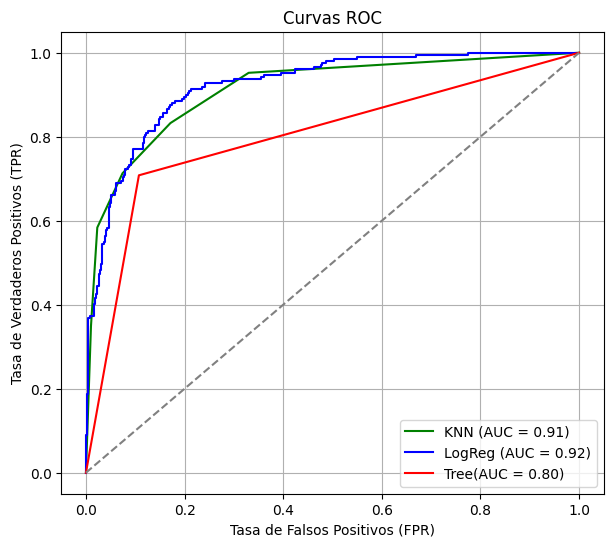

In [41]:
# cálculo de los elementos
# Curva ROC
fpr_test_knn, tpr_test_knn, _ = roc_curve(y_test, modelo_knn.predict_proba(X_test_s)[:,1])
fpr_test_log, tpr_test_log, _ = roc_curve(y_test, modelo_log.predict_proba(X_test_s)[:,1])
fpr_test_tree, tpr_test_tree, _ = roc_curve(y_test, modelo_tree.predict_proba(X_test)[:,1])

# AUC
auc_test_knn = roc_auc_score(y_test, modelo_knn.predict_proba(X_test_s)[:,1])
auc_test_log = roc_auc_score(y_test, modelo_log.predict_proba(X_test_s)[:,1])
auc_test_tree = roc_auc_score(y_test, modelo_tree.predict_proba(X_test)[:,1])

# Gráfica curva ROC
plt.figure(figsize=(7,6))
plt.plot(fpr_test_knn, tpr_test_knn, color='green', label=f'KNN (AUC = {auc_test_knn:.2f})')
plt.plot(fpr_test_log, tpr_test_log, color='blue', label=f'LogReg (AUC = {auc_test_log:.2f})')
plt.plot(fpr_test_tree, tpr_test_tree, color='red', label=f'Tree(AUC = {auc_test_tree:.2f})')

# Línea diagonal (azar)
plt.plot([0,1], [0,1], color='gray', linestyle='--')

# Detalles del gráfico
plt.xlabel("Tasa de Falsos Positivos (FPR)")
plt.ylabel("Tasa de Verdaderos Positivos (TPR)")
plt.title("Curvas ROC")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

conclusión: mejor modelo es regresión logística.